In [1]:
input_file='/data/work/yita/MetaNeighbor/GM_meta_metaNeighbor.rds'
output_name='zemi'
batch_key='biosample'
cluster_key='leiden_res_0.50'
threshold_value=0.80
k_clusters=10

In [7]:
library(MetaNeighbor)
library(SummarizedExperiment)
library(Seurat)
library(SingleCellExperiment)
library(grid)
library(ComplexHeatmap)
library(circlize)
library(ggplot2)
library(dplyr)
library(tidyr)
library(optparse)


Attaching package: ‘dplyr’


The following object is masked from ‘package:Biobase’:

    combine


The following objects are masked from ‘package:GenomicRanges’:

    intersect, setdiff, union


The following object is masked from ‘package:GenomeInfoDb’:

    intersect


The following objects are masked from ‘package:IRanges’:

    collapse, desc, intersect, setdiff, slice, union


The following objects are masked from ‘package:S4Vectors’:

    first, intersect, rename, setdiff, setequal, union


The following objects are masked from ‘package:BiocGenerics’:

    combine, intersect, setdiff, union


The following object is masked from ‘package:matrixStats’:

    count


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘tidyr’


The following object is masked from ‘package:S4Vectors’:

    expand




In [3]:
check_input <- function(input_file, batch_key){
    message("[check_input] Checking input files...")
    merged_data <- readRDS(input_file[[1]]); DefaultAssay(merged_data) <- "RNA"
    if (batch_key %in% colnames(merged_data@meta.data)) {
        print(paste0("Batch key ", batch_key, " found in metadata."))
    } else {
        prefix <- basename(input_file[[1]])
        merged_data@meta.data[[batch_key]] <- prefix
        print(paste0("Batch key ", batch_key, " not found. Added with value ", prefix, "."))
    }
    if (length(input_file) > 1) {
        message("[check_input] Merging additional input files...")
        for (i in 2:length(input_file)) {
            temp_data <- readRDS(input_file[[i]]); DefaultAssay(temp_data) <- "RNA"
            if (batch_key %in% colnames(temp_data@meta.data)) {
                print(paste0("Batch key ", batch_key, " found in metadata."))
            } else {
                prefix <- basename(input_file[[i]])
                temp_data@meta.data[[batch_key]] <- prefix
                print(paste0("Batch key ", batch_key, " not found. Added with value ", prefix, "."))
            }
            merged_data <- merge(merged_data, temp_data)
        }
    }
    tryCatch({
        print(merged_data$RNA@counts[1:5,1:5])
    }, error = function(e) {
        print(merged_data$RNA$counts[1:5,1:5])
    })
    message("> Printing metadata columns:")
    print(colnames(merged_data@meta.data))
    return(merged_data)
}

merged_data <-check_input(input_file, batch_key)

[check_input] Checking input files...



[1] "Batch key biosample found in metadata."
5 x 5 sparse Matrix of class "dgCMatrix"
                     yes1_CELL1_N1 yes1_CELL2_N4 yes1_CELL3_N1 yes1_CELL4_N1
evm.model.Contig1.1              .             .             .             .
evm.model.Contig1.10             .             .             .             .
evm.model.Contig1.11             .             1             .             1
evm.model.Contig1.2              .             .             .             .
evm.model.Contig1.3              .             .             .             .
                     yes1_CELL5_N1
evm.model.Contig1.1              .
evm.model.Contig1.10             1
evm.model.Contig1.11             .
evm.model.Contig1.2              .
evm.model.Contig1.3              .


> Printing metadata columns:



 [1] "orig.ident"                  "nCount_RNA"                 
 [3] "nFeature_RNA"                "sample"                     
 [5] "biosample"                   "n_genes_by_counts"          
 [7] "log1p_n_genes_by_counts"     "total_counts"               
 [9] "log1p_total_counts"          "pct_counts_in_top_50_genes" 
[11] "pct_counts_in_top_100_genes" "pct_counts_in_top_200_genes"
[13] "pct_counts_in_top_500_genes" "n_genes"                    
[15] "doublet_score"               "predicted_doublet"          
[17] "leiden_res_0.50"             "leiden_res_0.20"            
[19] "leiden_res_0.40"             "leiden_res_0.60"            
[21] "leiden_res_0.80"             "leiden_res_1.00"            
[23] "biosample|leiden_res_0.40"   "metaneighbor"               


In [4]:
run_metaneighbor <- function(merged_data, batch_key, cluster_key, output_name){
    message("[run_metaneighbor] Running MetaNeighbor analysis...")
    sdata <- as.SingleCellExperiment(merged_data, assay = "RNA", slot = "counts")
    # print(assay(sdata, "counts")[1:5, 1:5])
    # head(colData(sdata))
    var_genes = variableGenes(dat = sdata, exp_labels = sdata@colData[[batch_key]])
    celltype_NV = MetaNeighborUS(var_genes = var_genes,
                                dat = sdata,
                                study_id = sdata@colData[[batch_key]],
                                cell_type = sdata@colData[[cluster_key]],
                                fast_version = TRUE)
    return(celltype_NV)
}

celltype_NV <- run_metaneighbor(merged_data, batch_key, cluster_key, output_name)

[run_metaneighbor] Running MetaNeighbor analysis...

Warning message:
“The following arguments are not used: slot”
Warning message:
“Layer ‘data’ is empty”
Warning message:
“Layer ‘scale.data’ is empty”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 1.3 GiB”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 1.4 GiB”


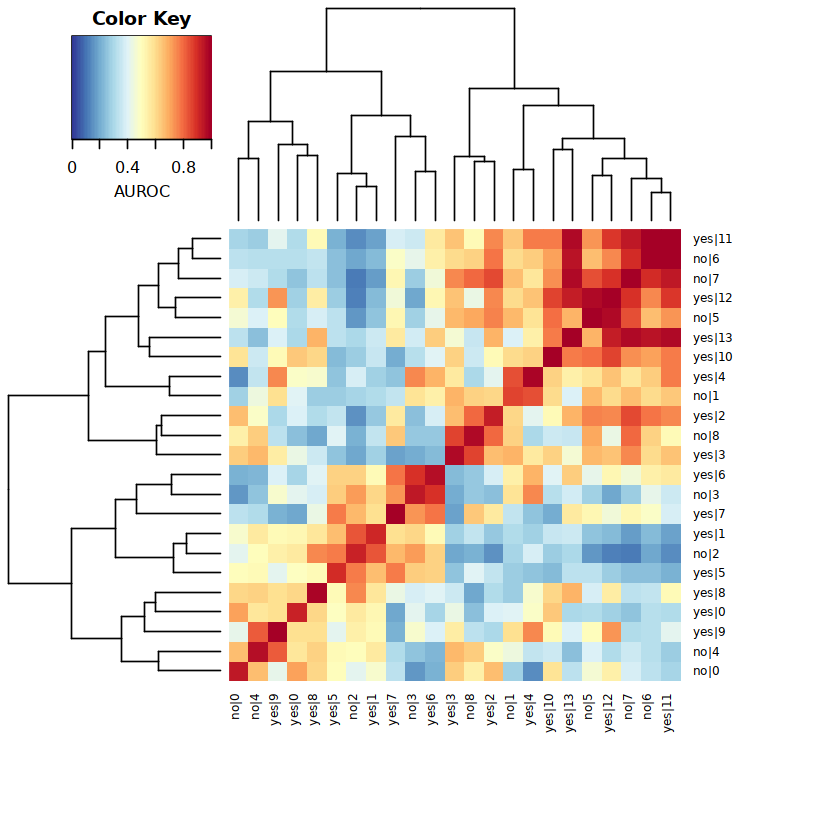

In [5]:
cols = rev(colorRampPalette(RColorBrewer::brewer.pal(11,"RdYlBu"))(100))
breaks = seq(0, 1, length=101)
gplots::heatmap.2(celltype_NV,
                  col = cols,
                  breaks = breaks,
                  key.xlab = "AUROC",
                  margins = c(8, 8),
                  trace = "none",
                  density.info = "none",
                  offsetRow=0.1,
                  offsetCol=0.1,
                  cexRow = 0.7,
                  cexCol = 0.7)

In [11]:
# cluster
determine_optimal_k <- function(data, kmax = 10) {
  library(factoextra)
  library(NbClust)
  library(cluster)
  # 1. 计算三种核心指标
  sil <- fviz_nbclust(data, hcut, method = "silhouette", k.max = kmax)
  gap <- clusGap(data, FUN = hcut, K.max = kmax, B = 50)
  # 2. 获取各方法推荐
  best_sil <- sil$data$clusters[which.max(sil$data$y)]
  best_gap <- maxSE(gap$Tab[, "gap"], gap$Tab[, "SE.sim"])
  nb <- NbClust(data, min.nc = 2, max.nc = kmax, method = "ward.D2")
  best_nb <- as.numeric(names(which.max(table(nb$Best.nc[1,]))))
  # 3. 共识投票
  votes <- c(sil = best_sil, gap = best_gap, nb = best_nb)
  result <- list(
    optimal_k = as.numeric(names(which.max(table(votes)))),
    all_votes = votes,
    tie = length(unique(votes)) > 1 && max(table(votes)) == 1
  )
  # 平票时选silhouette
  if(result$tie) result$optimal_k <- best_sil
  message("最佳k:", result$optimal_k, "\n")
  message("投票详情:", result$all_votes, "\n")
  return(result)
}

add_cluster <- function(celltype_NV, k, merged_data, batch_key, cluster_key){
  final_k <- tryCatch({
    determine_optimal_k(celltype_NV, kmax=k)$optimal_k
  }, error = function(e) {
    k
  })
  # 1. 计算行列聚类
  row_hclust <- hclust(dist(celltype_NV))
  # 2. 获取分群信息（切割树获得分组）
  row_groups <- cutree(row_hclust, k = final_k)
  # 转换为数据框便于操作
  cluster_df <- data.frame(
    combined_key = names(row_groups),
    metaneighbor = as.vector(row_groups),
    stringsAsFactors = FALSE
  ) %>%
    # 拆分 combined_key 获取 batch 和 cluster
    separate(combined_key, into = c(batch_key, cluster_key), sep = "\\|", remove = FALSE)
  cluster_df$metaneighbor <- paste0("cluster_", as.character(cluster_df$metaneighbor))
  message("[add_cluster] MetaNeighbor clustering completed. Cluster assignments:")
  print(cluster_df)
  # ========== 2. 创建映射字典 ==========
  group2cluster <- setNames(cluster_df$metaneighbor, cluster_df$combined_key)
  combined_key <- paste0(batch_key, "|", cluster_key)
  message("[add_cluster] Adding MetaNeighbor cluster annotations to metadata...")
  merged_data@meta.data[[combined_key]] <- paste0(merged_data@meta.data[[batch_key]], "|", merged_data@meta.data[[cluster_key]])
  # 映射 MetaNeighbor 分群结果
  merged_data@meta.data$metaneighbor <- group2cluster[merged_data@meta.data[[combined_key]]]
  message("[add_cluster] MetaNeighbor cluster annotation added. Distribution:")
  print(table(merged_data@meta.data$metaneighbor))
  return(merged_data)
}

merged_data <- add_cluster(celltype_NV, k_clusters, merged_data, batch_key, cluster_key)

Warning message in log(det(P)/det(W)):
“NaNs produced”
[add_cluster] MetaNeighbor clustering completed. Cluster assignments:



   combined_key biosample leiden_res_0.50 metaneighbor
1         yes|0       yes               0    cluster_1
2         yes|1       yes               1    cluster_2
3        yes|10       yes              10    cluster_3
4        yes|11       yes              11    cluster_4
5        yes|12       yes              12    cluster_4
6        yes|13       yes              13    cluster_3
7         yes|2       yes               2    cluster_5
8         yes|3       yes               3    cluster_5
9         yes|4       yes               4    cluster_6
10        yes|5       yes               5    cluster_2
11        yes|6       yes               6    cluster_7
12        yes|7       yes               7    cluster_8
13        yes|8       yes               8    cluster_1
14        yes|9       yes               9    cluster_9
15         no|0        no               0   cluster_10
16         no|1        no               1    cluster_6
17         no|2        no               2    cluster_2
18        

[add_cluster] Adding MetaNeighbor cluster annotations to metadata...

[add_cluster] MetaNeighbor cluster annotation added. Distribution:




 cluster_1 cluster_10  cluster_2  cluster_3  cluster_4  cluster_5  cluster_6 
      1859       3520       3339        174       1203       2106       2972 
 cluster_7  cluster_8  cluster_9 
      1625        474        278 


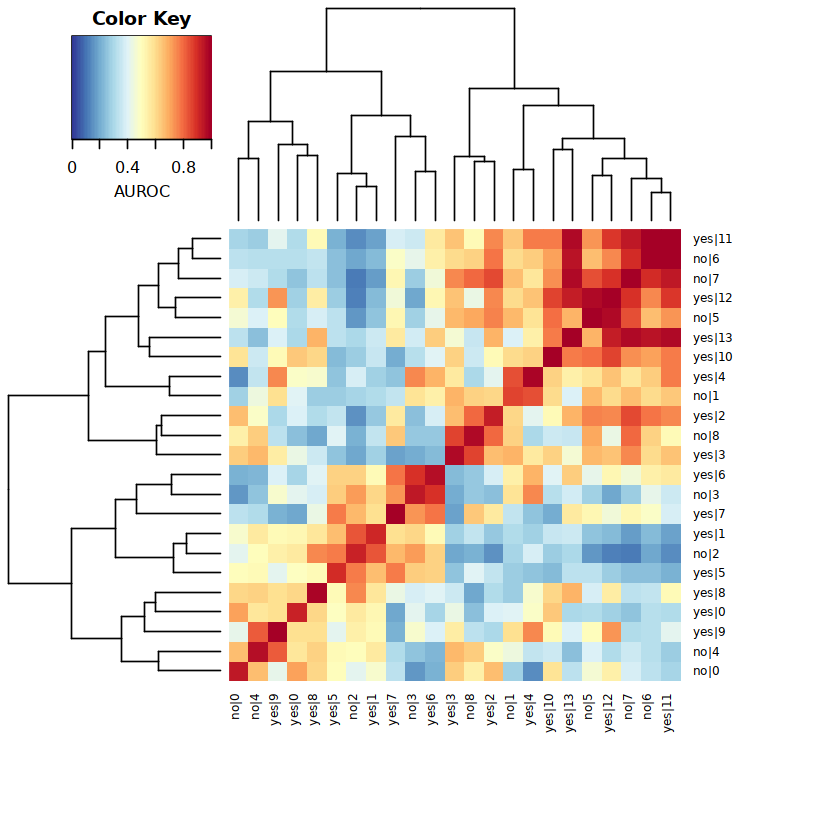

In [8]:
cols = rev(colorRampPalette(RColorBrewer::brewer.pal(11,"RdYlBu"))(100))
breaks = seq(0, 1, length=101)
gplots::heatmap.2(celltype_NV,
                  col = cols,
                  breaks = breaks,
                  key.xlab = "AUROC",
                  margins = c(8, 8),
                  trace = "none",
                  density.info = "none",
                  offsetRow=0.1,
                  offsetCol=0.1,
                  cexRow = 0.7,
                  cexCol = 0.7)

In [16]:
# cluster
determine_optimal_k <- function(data, kmax = 10) {
  library(factoextra)
  library(NbClust)
  # 1. 计算三种核心指标
  sil <- fviz_nbclust(data, hcut, method = "silhouette", k.max = kmax)
  gap <- clusGap(data, FUN = hcut, K.max = kmax, B = 50)
  # 2. 获取各方法推荐
  best_sil <- sil$data$clusters[which.max(sil$data$y)]
  best_gap <- maxSE(gap$Tab[, "gap"], gap$Tab[, "SE.sim"])
  nb <- NbClust(data, min.nc = 2, max.nc = kmax, method = "ward.D2")
  best_nb <- as.numeric(names(which.max(table(nb$Best.nc[1,]))))
  # 3. 共识投票
  votes <- c(sil = best_sil, gap = best_gap, nb = best_nb)
  result <- list(
    optimal_k = as.numeric(names(which.max(table(votes)))),
    all_votes = votes,
    tie = length(unique(votes)) > 1 && max(table(votes)) == 1
  )
  # 平票时选silhouette
  if(result$tie) result$optimal_k <- best_sil
  return(result)
}

add_cluster <- function(celltype_NV, k, merged_data, batch_key, cluster_key){
  final_k <- tryCatch({
    determine_optimal_k(celltype_NV, kmax=k)$optimal_k
  }, error = function(e) {
    k
  })
  # 1. 计算行列聚类
  row_hclust <- hclust(dist(celltype_NV))
  # 2. 获取分群信息（切割树获得分组）
  row_groups <- cutree(row_hclust, k = final_k)
  # 转换为数据框便于操作
  cluster_df <- data.frame(
    combined_key = names(row_groups),
    metaneighbor = as.vector(row_groups),
    stringsAsFactors = FALSE
  ) %>%
    # 拆分 combined_key 获取 batch 和 cluster
    separate(combined_key, into = c(batch_key, cluster_key), sep = "\\|", remove = FALSE)
  cluster_df$metaneighbor <- paste0("cluster_", as.character(cluster_df$metaneighbor))
  print(cluster_df)
  # ========== 2. 创建映射字典 ==========
  group2cluster <- setNames(cluster_df$metaneighbor, cluster_df$combined_key)
  combined_key <- paste0(batch_key, "|", cluster_key)
  merged_data@meta.data[[combined_key]] <- paste0(merged_data@meta.data[[batch_key]], "|", merged_data@meta.data[[cluster_key]])
  # 映射 MetaNeighbor 分群结果
  merged_data@meta.data$metaneighbor <- group2cluster[merged_data@meta.data[[combined_key]]]
  print(table(merged_data@meta.data$metaneighbor))
  return(merged_data)
}


In [17]:
merged_data <- add_cluster(celltype_NV, k_clusters, merged_data, batch_key, cluster_key)

Warning message in log(det(P)/det(W)):
“NaNs produced”


   combined_key biosample leiden_res_0.50 metaneighbor
1         yes|0       yes               0    cluster_1
2         yes|1       yes               1    cluster_2
3        yes|10       yes              10    cluster_3
4        yes|11       yes              11    cluster_4
5        yes|12       yes              12    cluster_4
6        yes|13       yes              13    cluster_3
7         yes|2       yes               2    cluster_5
8         yes|3       yes               3    cluster_5
9         yes|4       yes               4    cluster_6
10        yes|5       yes               5    cluster_2
11        yes|6       yes               6    cluster_7
12        yes|7       yes               7    cluster_8
13        yes|8       yes               8    cluster_1
14        yes|9       yes               9    cluster_9
15         no|0        no               0   cluster_10
16         no|1        no               1    cluster_6
17         no|2        no               2    cluster_2
18        